In [1]:
# Pour la manipulation de tableaux
import numpy as np
import pandas as pd

# Imports nécessaires pour construire un modèle LeNet avec l'API fonctionnelle de Keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling


# Pour encoder les labels
from tensorflow.keras.utils import to_categorical

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

import itertools


In [2]:
import os
import numpy as np
from keras.utils import load_img, img_to_array

def load_dataset_from_directory(base_dir, img_size, color_mode):
    X = []
    y = []
    class_names = []

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        class_index = len(class_names) - 1

        for root, dirs, files in os.walk(class_path):
            for filename in files:
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    file_path = os.path.join(root, filename)

                    img = load_img(file_path, target_size=img_size, color_mode=color_mode)
                    img_array = img_to_array(img)

                    X.append(img_array)
                    y.append(class_index)

    return np.array(X), np.array(y), class_names

In [3]:
chemin_good=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Train"
chemin_test=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Test"
from tensorflow.keras.preprocessing.image import load_img, img_to_array

train_dir = chemin_good
test_dir  = chemin_test

img_size = (128, 128)   # 
color_mode = "rgb"  # ou "grayscale"


X_train, y_train, class_names_train = load_dataset_from_directory(train_dir, img_size, color_mode)
X_test, y_test, class_names_test = load_dataset_from_directory(test_dir, img_size, color_mode)


# Shape de X_train and y_train
print('Shape of X:', X_train.shape)
print('Shape of y:', y_train.shape)



Shape of X: (5865, 128, 128, 3)
Shape of y: (5865,)


In [4]:
y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test) 

# La méthode *utils.to_categorical* transforme les chiffres en vecteurs
# remplis de zéros, sauf à la position du chiffre en question qui vaut 1 
# Par exemple, 3 devient (0,0,0,1,0,0,0,0,0,0)

# Ainsi y_train et y_test deviennent des matrices de mêmes nombres de lignes mais avec autant
# de colonnes que de classes (chiffres uniques) qu'elles possèdent.

In [5]:
#visualisation du résoltat d'encoding
df_y_train=pd.DataFrame(y_train)
df_y_train
df_y_train_encoded=pd.DataFrame(y_train_encoded)
df_y_train_encoded


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5863,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [7]:
# Architecture du modèle
inputs = Input(shape=(128, 128, 3))

normalization_layer = Rescaling(1./255)

# Première couche de convolution
conv_1 = Conv2D(
    filters=30,                    # Nombre de filtres
    kernel_size=(5, 5),            # Dimensions du noyau
    padding='valid',               # Mode de Dépassement
    activation='relu',             # Fonction d'activation
)

# Première couche de pooling
max_pool_1 = MaxPooling2D(pool_size=(2, 2),)

# Deuxième couche de convolution
conv_2 = Conv2D(
    filters=16,                    
    kernel_size=(3, 3),          
    padding='valid',             
    activation='relu',
)

# Deuxième couche de pooling
max_pool_2 = MaxPooling2D(pool_size=(2, 2),)

# Couche de dropout
dropout = Dropout(0.2)

# Couche de Flatten
flatten = Flatten()

# Première couche dense
dense_1 = Dense(
    units=128,
    activation='relu',
)

# Couche de sortie
dense_2 = Dense(
    units=15,
    activation='softmax',
)


# Extraction des caractéristqiues
x = normalization_layer(inputs)
x = conv_1(x)
x = max_pool_1(x)
x = conv_2(x)
x = max_pool_2(x)
x = dropout(x)

# Applatissement 
x = flatten(x)

# Couches dense pour la prédiction 
x = dense_1(x)
outputs = dense_2(x)

lenet = Model(inputs=inputs, outputs=outputs)

#####################
lenet.compile(loss='categorical_crossentropy',  # fonction de perte
              optimizer='adam',                 # algorithme de descente de gradient
              metrics=['accuracy'])             # métrique d'évaluation



In [8]:
from sklearn.utils import shuffle

X_train, y_train_encoded = shuffle(
    X_train,
    y_train_encoded,
    random_state=42
)

training_history_lenet = lenet.fit(X_train, y_train_encoded,           # données
                                   validation_split=0.2,       # split de test
                                   epochs=15,                  # nombre d'epochs
                                   batch_size=128)             # taille des batchs


Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 323ms/step - accuracy: 0.7413 - loss: 0.7950 - val_accuracy: 0.8653 - val_loss: 0.2427
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.9454 - loss: 0.1425 - val_accuracy: 0.9454 - val_loss: 0.1260
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 317ms/step - accuracy: 0.9546 - loss: 0.1272 - val_accuracy: 0.9864 - val_loss: 0.0547
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 318ms/step - accuracy: 0.9881 - loss: 0.0368 - val_accuracy: 0.9378 - val_loss: 0.1477
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.9834 - loss: 0.0456 - val_accuracy: 0.9966 - val_loss: 0.0234
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 321ms/step - accuracy: 0.9917 - loss: 0.0214 - val_accuracy: 0.9881 - val_loss: 0.0336
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 316ms/step - accuracy: 0.9942 - loss: 0.0190 - val_accuracy: 0.9966 - val_loss: 0.0152
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step - accuracy: 0.9985 - loss: 0.0076 - val_accu

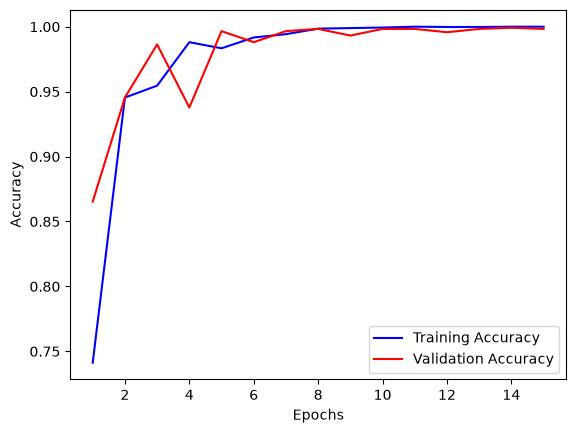

In [10]:
################"
train_acc_lenet = training_history_lenet.history['accuracy']
val_acc_lenet = training_history_lenet.history['val_accuracy']


###################
# Labels des axes
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Courbe de la précision sur l'échantillon d'entrainement
plt.plot(np.arange(1 , 16, 1),
         training_history_lenet.history['accuracy'],
         label='Training Accuracy',
         color='blue')

# Courbe de la précision sur l'échantillon de test
plt.plot(np.arange(1 , 16, 1),
         training_history_lenet.history['val_accuracy'], 
         label='Validation Accuracy',
         color='red')

# Affichage de la légende
plt.legend()

# Affichage de la figure
plt.show()


In [11]:
###############
test_pred = lenet.predict(X_test)

test_pred_class = test_pred.argmax(axis=1)

y_test_class = y_test_encoded.argmax(axis=1)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       132
           3       1.00      1.00      1.00       117
           4       1.00      1.00      1.00        78
           5       1.00      1.00      1.00       110
           6       1.00      1.00      1.00       124
           7       1.00      1.00      1.00       115
           8       1.00      1.00      1.00       167
           9       1.00      1.00      1.00       160
          10       1.00      1.00      1.00       117
          11       1.00      1.00      1.00        42
          12       1.00      1.00      1.00       100
          13       1.00      1.00      1.00        79
          14       1.00      1.00      1.00       151

    accuracy                           1.00      1725
   macro avg       1.00      1.00      1.00      1725
weighted avg       1.00   

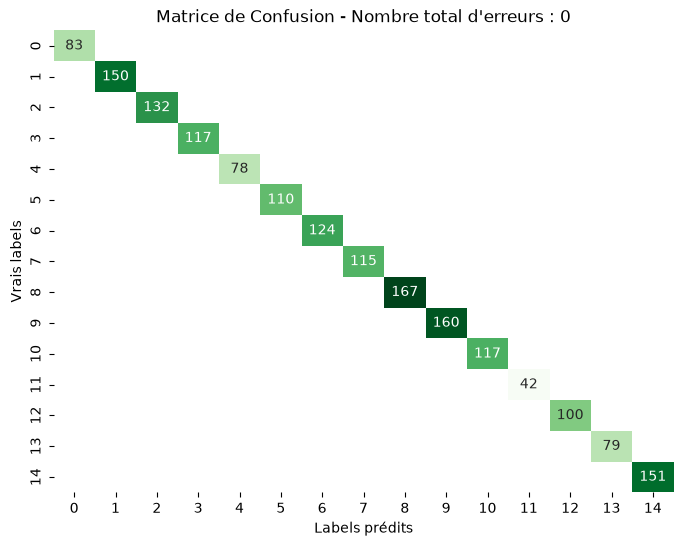

In [12]:
##############
print(metrics.classification_report(y_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)
mask=(cnf_matrix ==0)

#nb total erreurs
nb_erreurs = cnf_matrix.sum() - np.trace(cnf_matrix)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de Confusion - Nombre total d'erreurs : "+str(nb_erreurs))
sns.heatmap(cnf_matrix, cmap='Greens', mask=mask, annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


In [13]:
for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    if cnf_matrix[i, j] > 0.000 and i != j:  # Seuil de 0.0% pour les erreurs significatives
        print(f"{cnf_matrix[i, j]:.0f} des instances de la catégorie {i} ont été classées comme {j}.")

In [14]:
############ Défauts
enr_defauts=[]
for i in range(1,len(y_test)):
        if y_test_class[i] != test_pred_class[i]:
            enr_defauts.append(i)
            
print(len(enr_defauts))
print(enr_defauts)

nb_img_par_couche=10
    
j = 1
plt.figure(figsize=(20, 20))
y_prec=0
num_sortis=[]
print(len(y_test))
for i in enr_defauts:
    img = X_test[i].reshape(128, 128, 3).astype(np.uint8)

    plt.subplot((nb_erreurs // nb_img_par_couche) + 1, nb_img_par_couche, j)
    plt.axis('off')
    plt.imshow(img)

    plt.title(
        f"réel: {class_names_train[y_test_class[i]]}\nPred: {class_names_train[test_pred_class[i]]}",
        fontsize=8
    )
    
    j += 1

               
plt.tight_layout()
plt.show()

0
[]
1725


<Figure size 2000x2000 with 0 Axes>